# Day 048 — Advanced Feature Engineering
**AI/ML 365-Day Roadmap — Sahil Kumar**

---

## 1. Missing Value Imputation

### Types of Missingness:
| Type | Meaning | Example |
|---|---|---|
| **MCAR** (Missing Completely At Random) | No pattern to missingness | Data entry errors randomly |
| **MAR** (Missing At Random) | Missingness depends on other observed features | Older people less likely to fill income |
| **MNAR** (Missing Not At Random) | Missingness depends on the missing value itself | High earners hide income |

### Imputation Methods:

| Method | When to Use | Sklearn Syntax |
|---|---|---|
| **Mean** | Numeric, normally distributed, few missing | `SimpleImputer(strategy='mean')` |
| **Median** | Numeric, skewed distributions, outliers present | `SimpleImputer(strategy='median')` |
| **Mode (Most Frequent)** | Categorical features | `SimpleImputer(strategy='most_frequent')` |
| **Constant** | When missingness itself is a signal | `SimpleImputer(strategy='constant', fill_value=-1)` |
| **KNN Imputer** | When features are correlated, captures local patterns | `KNNImputer(n_neighbors=5)` |

### New Syntax:
```python
from sklearn.impute import SimpleImputer, KNNImputer

# SimpleImputer
imp = SimpleImputer(strategy='median')    # or 'mean', 'most_frequent', 'constant'
X_imputed = imp.fit_transform(X)          # fit on train, transform both
print(imp.statistics_)                     # learned fill values

# KNNImputer — uses k nearest neighbors to estimate missing values
knn_imp = KNNImputer(n_neighbors=5, weights='uniform')  # or weights='distance'
X_knn = knn_imp.fit_transform(X)
```

### ⚠️ Important:
- Always **fit imputer on training set only**, then `transform()` test set
- Use inside `Pipeline` to prevent leakage
- KNNImputer only works on **numeric** features

---

## 2. Outlier Detection

### Method 1: IQR (Interquartile Range)
```
IQR = Q3 - Q1
Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
Outlier: x < Lower Bound  OR  x > Upper Bound
```

- Q1 = 25th percentile, Q3 = 75th percentile
- Factor 1.5 is standard; use 3.0 for extreme outliers only
- **Robust** — not affected by the outliers themselves

### Method 2: Z-Score
```
z = (x - μ) / σ
Outlier: |z| > 3  (more than 3 standard deviations from mean)
```

- Assumes roughly normal distribution
- **Sensitive** to extreme outliers (they shift μ and σ)
- Use IQR for non-normal data, Z-Score for roughly normal data

### Handling Outliers:
| Strategy | When |
|---|---|
| **Remove** | Clearly wrong data (data entry errors) |
| **Clip/Cap** | Want to keep the observation but reduce its influence |
| **Transform** | Log, sqrt, Box-Cox to reduce skewness |
| **Keep** | Outlier IS the signal (fraud detection, anomaly detection) |

---

## 3. Encoding Categorical Variables

### One-Hot Encoding (OHE)
- Creates **binary dummy columns** for each category
- Use for **nominal** categories (no natural order): city, color, country
- ⚠️ Use `drop='first'` to avoid **dummy variable trap** (multicollinearity)

```python
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    sparse_output=False,     # Return dense array (not sparse matrix)
    drop='first',            # Drop first column to avoid collinearity
    handle_unknown='ignore'  # Handle unseen categories at test time
)
X_encoded = ohe.fit_transform(df[['city']])
print(ohe.get_feature_names_out(['city']))  # Column names
```

### Label Encoding (Ordinal)
- Maps categories to integers: `{Low: 0, Medium: 1, High: 2}`
- Use ONLY for **ordinal** categories (natural order exists)
- ⚠️ NEVER use for nominal data — model will assume 2 > 1 > 0

```python
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])  # Specify order!
X_ord = oe.fit_transform(df[['risk_level']])
```

### Target Encoding
- Replace each category with the **mean of the target** for that category
- Great for **high cardinality** categoricals (100+ unique values)
- ⚠️ **Massive leakage risk** — MUST compute target mean on TRAIN set only

```python
# Manual target encoding (inside CV fold only!)
target_means = train_df.groupby('city')['target'].mean()
train_df['city_encoded'] = train_df['city'].map(target_means)
test_df['city_encoded'] = test_df['city'].map(target_means)  # Use TRAIN means!
```

---

## 4. Power Transformers (Fixing Skewed Distributions)

**Problem**: Many ML algorithms (Linear Regression, SVM, KNN) assume features are roughly normally distributed. Heavily skewed features hurt performance.

| Method | Formula | Handles Negatives? | When to Use |
|---|---|---|---|
| **Box-Cox** | y(λ) = (x^λ - 1) / λ | ❌ Only positive values | Income, prices, counts |
| **Yeo-Johnson** | Extension of Box-Cox | ✅ Any values | General purpose |
| **Log Transform** | y = log(x+1) | ❌ Only positive | Quick fix for right-skewed data |

```python
from sklearn.preprocessing import PowerTransformer

# Box-Cox (positive data only)
pt_bc = PowerTransformer(method='box-cox')  # Automatically finds best λ
X_bc = pt_bc.fit_transform(X_positive)

# Yeo-Johnson (any data)
pt_yj = PowerTransformer(method='yeo-johnson')
X_yj = pt_yj.fit_transform(X_any)

print(pt_bc.lambdas_)  # Learned λ values per feature
```

### When Power Transforms DON'T matter:
- **Tree-based models** (Decision Tree, RF, XGBoost) are **invariant** to monotonic transforms
- They split on thresholds, so scaling/transforming doesn't change the splits
- Only use Power Transforms for: Linear models, SVM, KNN, Neural Networks

---

## 5. Feature Scaling

| Scaler | Formula | Output Range | Best For | Sensitive to Outliers? |
|---|---|---|---|---|
| **StandardScaler** | z = (x - μ) / σ | ~[-3, +3] | Normally distributed features | ⚠️ Yes |
| **MinMaxScaler** | x' = (x - min) / (max - min) | [0, 1] | Bounded features, neural networks | ⚠️ Yes |
| **RobustScaler** | x' = (x - median) / IQR | Varies | Data with outliers | ✅ No |

```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = RobustScaler()          # Best when outliers present
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform!
```

### Which models NEED scaling?
| Needs Scaling ✅ | Doesn't Need Scaling ❌ |
|---|---|
| Logistic Regression, SVM, KNN, Neural Networks, PCA | Decision Trees, Random Forest, XGBoost, LightGBM, Naive Bayes |

---

## 🧪 Practice Tasks

1. Create a messy dataset with `np.random.seed(42)`: age (int), income (exponential), credit_score (normal), education (categorical), city (categorical), target (binary)
2. Inject ~10% missing values in age, income, education
3. Inject 2-3 extreme outliers in income
4. **Imputation**: Apply `SimpleImputer(median)` on numeric, `SimpleImputer(most_frequent)` on categorical, also try `KNNImputer`
5. **Outlier Detection**: Compute IQR bounds and Z-scores for income. Count outliers with each method. Plot boxplot + histogram
6. **Encoding**: One-Hot encode city (with `drop='first'`), Ordinal encode education, Target encode city
7. **Power Transform**: Apply Box-Cox and Yeo-Johnson on income. Plot 3 histograms (original, box-cox, yeo-johnson) with skewness values using `pd.Series.skew()`
8. **Scaling**: Scale income with all 3 scalers. Plot 4 histograms comparing original vs each scaler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
n_samples = 1000

In [3]:
age =np.random.randint(18,70,size=n_samples).astype(float)

In [4]:
income=np.random.exponential(scale=50000,size=n_samples)

In [5]:
from sklearn.impute import SimpleImputer,KNNImputer

In [6]:
credit=np.random.normal(loc=650,scale=100,size=n_samples)

In [10]:
education =np.random.choice(['High school','Bechelor','Master','Phd'],size=n_samples)

In [9]:
city = np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Pune'], size=n_samples)
target = np.random.choice([0, 1], size=n_samples)

In [11]:
df=pd.DataFrame({
    'age':age,
    'income':income,
    'credit':credit,
    'education':education,
    'city':city,
    'target':target})

In [12]:
df

,age,income,credit,education,city,target
0,56.0,38030.339953,540.768724,High school,Pune,0
1,69.0,13884.640163,618.359155,Phd,Pune,1
2,46.0,15683.730594,771.309770,High school,Bangalore,1
3,32.0,23683.249240,664.171691,Master,Delhi,1
4,60.0,1013.768038,881.932954,Master,Bangalore,1
...,...,...,...,...,...,...
995,60.0,21352.688074,681.965183,High school,Delhi,1
996,64.0,54668.063644,599.582017,Bechelor,Mumbai,1
997,62.0,79347.132146,641.847733,Phd,Pune,1
998,35.0,130986.734635,684.767648,High school,Pune,1


In [13]:
df.isnull().sum()

age          0
income       0
credit       0
education    0
city         0
target       0
dtype: int64

<Axes: xlabel='age', ylabel='count'>

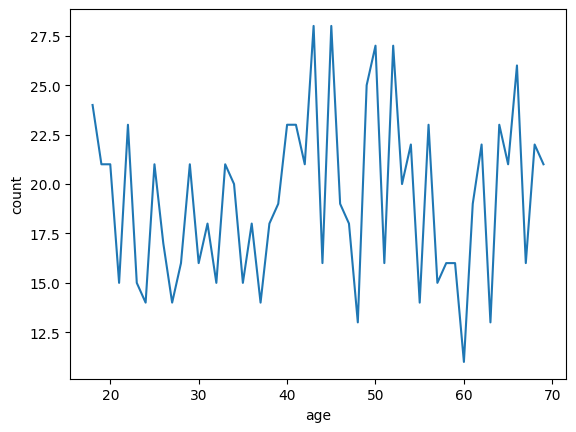

In [15]:
sns.lineplot(df['age'].value_counts())

<Axes: ylabel='Frequency'>

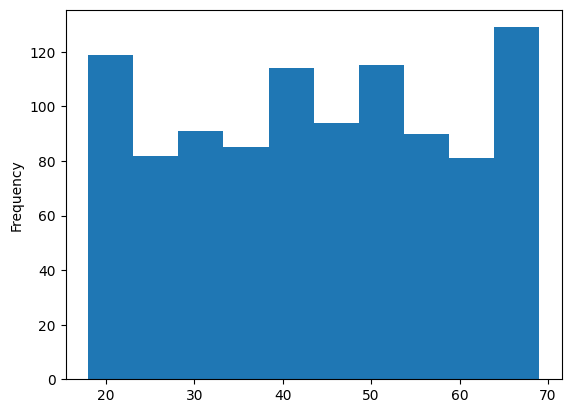

In [16]:
df['age'].plot(kind='hist')

In [17]:
# Task 2: Inject ~10% missing values
for col in ['age', 'income', 'education']:
    mask = np.random.rand(n_samples) < 0.10
    df.loc[mask, col] = np.nan

In [18]:
valid_income_ind=df[df['income'].notnull()].index

In [19]:
outlier_indices=np.random.choice(valid_income_ind,size=3,replace=True)

In [20]:
df.loc[outlier_indices, 'income'] = [1500000, 2000000, 1800000]

In [21]:
df.isnull().sum()

age           93
income       107
credit         0
education    110
city           0
target         0
dtype: int64

In [22]:
df['income'].describe()

count    8.930000e+02
mean     5.648946e+04
std      1.123578e+05
min      2.321392e+02
25%      1.353973e+04
50%      3.657757e+04
75%      6.930681e+04
max      2.000000e+06
Name: income, dtype: float64

In [23]:
num_cols=['age','income','credit']
imp_median=SimpleImputer(strategy='median')

In [24]:
df[num_cols]=imp_median.fit_transform(df[num_cols])

In [25]:
df.isnull().sum()

age            0
income         0
credit         0
education    110
city           0
target         0
dtype: int64

In [26]:
imp_mode=SimpleImputer(strategy='most_frequent')

In [27]:
df[['education']]=imp_mode.fit_transform(df[['education']])

In [28]:
df.isnull().sum()

age          0
income       0
credit       0
education    0
city         0
target       0
dtype: int64

In [29]:
knn_imp=KNNImputer(n_neighbors=5)

In [30]:
# Naya dataset copy banayein
df_knn_raw = pd.DataFrame({
    'age': age,
    'income': income,
    'credit': credit
})

# Missing values inject karein
for col in ['age', 'income']:
    mask = np.random.rand(n_samples) < 0.10
    df_knn_raw.loc[mask, col] = np.nan

In [31]:
df_knn_raw.isnull().sum()

age       101
income     89
credit      0
dtype: int64

In [35]:
df_knn_imp=pd.DataFrame(knn_imp.fit_transform(df_knn_raw),columns=df_knn_raw.columns)

In [37]:
df_knn_imp.isnull().sum()

age       0
income    0
credit    0
dtype: int64

In [38]:
# Task 5: IQR Method for Income
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]
print(f"IQR Outliers Count: {len(iqr_outliers)}")

IQR Outliers Count: 66


In [39]:
# Task 5 (Part 2): Z-Score Method for Income
mean_income = df['income'].mean()
std_income = df['income'].std()

z_scores = (df['income'] - mean_income) / std_income
z_outliers = df[np.abs(z_scores) > 3]

print(f"Z-Score Outliers Count: {len(z_outliers)}")

Z-Score Outliers Count: 3


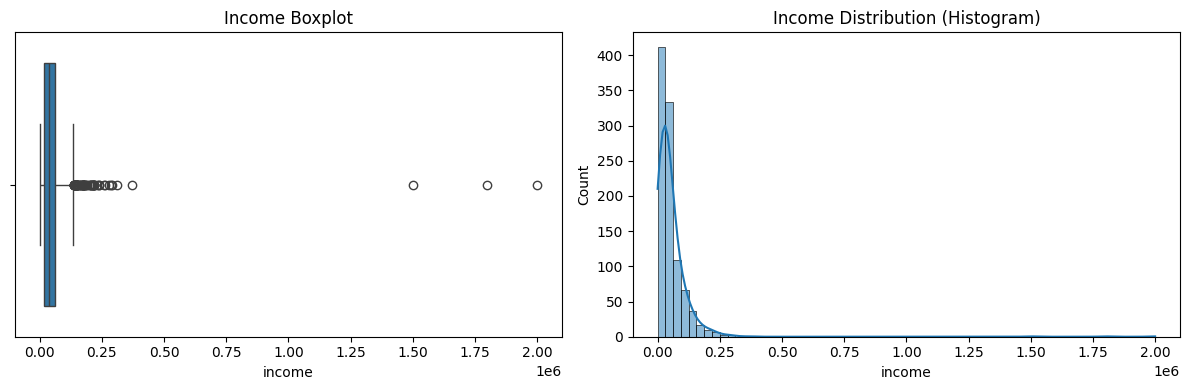

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
sns.boxplot(x=df['income'], ax=axes[0])
axes[0].set_title('Income Boxplot')

# Histogram
sns.histplot(df['income'], kde=True, ax=axes[1])
axes[1].set_title('Income Distribution (Histogram)')

plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import OneHotEncoder

In [42]:
ohe=OneHotEncoder(drop='first',sparse_output=False)

In [43]:
city_ohe=ohe.fit_transform(df[['city']])

In [44]:
df_city_ohe = pd.DataFrame(city_ohe, columns=ohe.get_feature_names_out(['city']))
df_city_ohe.head()

,city_Delhi,city_Mumbai,city_Pune
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0


In [45]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
# Education levels ka order define karein (Low to High)
education_order = ['High school', 'Bechelor', 'Master', 'Phd']

# OrdinalEncoder instantiate karein
oe = OrdinalEncoder(categories=[education_order])

# Fit transform karke new column banayein
df['education_encoded'] = oe.fit_transform(df[['education']])

# Result check karein
df[['education', 'education_encoded']].head()

,education,education_encoded
0,Master,2.0
1,Phd,3.0
2,High school,0.0
3,Master,2.0
4,Master,2.0


In [47]:
city_target_mean=df.groupby('city')['target'].mean()

In [48]:
# City target encoding apply kareinidx][col].map(means)
    df[f"{col}_encoded"].filln
df['city_target_encoded'] = df['city'].map(city_target_mean)

# Verify karne ke liye display karein
df[['city', 'city_target_encoded']].head()

,city,city_target_encoded
0,Pune,0.488722
1,Pune,0.488722
2,Bangalore,0.550000
3,Delhi,0.504274
4,Bangalore,0.550000


In [49]:
from sklearn.model_selection import KFold

def kfold_target_encode(df, col, target, n_splits=5):
    df = df.copy()
    df[f"{col}_encoded"] = 0.0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df):
        means = df.iloc[train_idx].groupby(col)[target].mean()
        df.loc[df.index[val_idx], f"{col}_encoded"] = df.iloc[val_idx][col].map(means)
    df[f"{col}_encoded"].fillna(df[target].mean(), inplace=True)
    return df

# K-Fold Target Encoding Apply Karein
df = kfold_target_encode(df, col="city", target="target")

# Output Verify Karein
df[['city', 'city_encoded']].head()

,city,city_encoded
0,Pune,0.506849
1,Pune,0.495536
2,Bangalore,0.519417
3,Delhi,0.485876
4,Bangalore,0.571429


In [50]:
from sklearn.preprocessing import PowerTransformer

In [51]:
pt_bc=PowerTransformer(method='box-cox')

In [52]:
income_bc=pt_bc.fit_transform(df[['income']])

In [53]:
pt_yj = PowerTransformer(method='yeo-johnson')   # general purpose
income_yj = pt_yj.fit_transform(df[['income']])

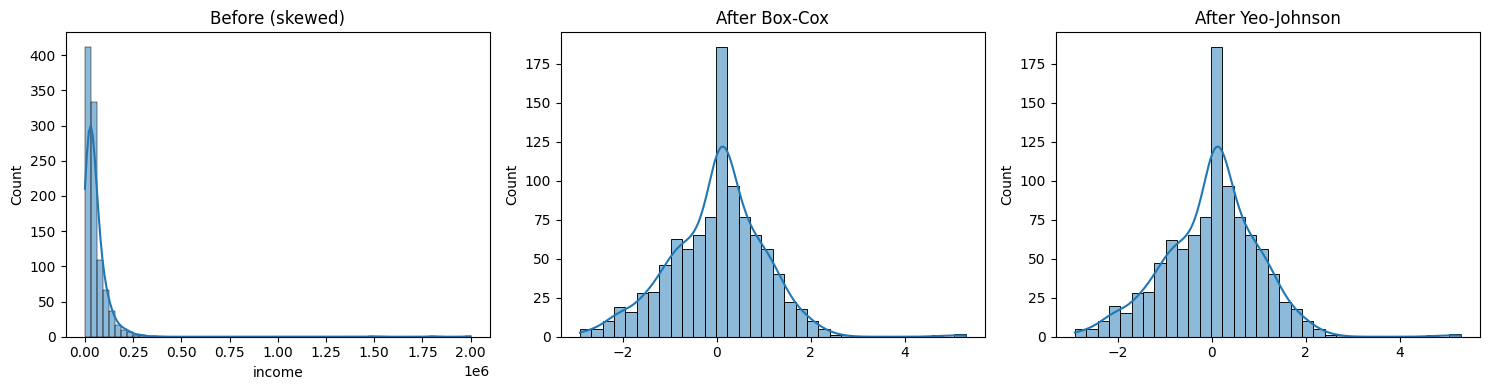

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['income'], kde=True, ax=axes[0])
axes[0].set_title("Before (skewed)")

sns.histplot(income_bc.ravel(), kde=True, ax=axes[1])
axes[1].set_title("After Box-Cox")

sns.histplot(income_yj.ravel(), kde=True, ax=axes[2])
axes[2].set_title("After Yeo-Johnson")

plt.tight_layout()
plt.show()

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

# Column groups define karo
numeric_cols = ['age', 'income', 'credit']
categorical_cols = ['city', 'education']

# Final combined preprocessing pipeline
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scale", RobustScaler()),
    ]), numeric_cols),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

# Apply karo poore dataframe pe
X_ready = preprocess.fit_transform(df)

print("Final shape:", X_ready.shape)
print(X_ready[:5])

Final shape: (1000, 11)
[[ 0.55129791  0.02856269 -0.84389817  0.          0.          0.
   1.          0.          0.          1.          0.        ]
 [ 1.07991247 -0.65065033 -0.25101772  0.          0.          0.
   1.          0.          0.          0.          1.        ]
 [ 0.12959336  0.          0.94285228  1.          0.          0.
   0.          0.          1.          0.          0.        ]
 [-0.49022502 -0.30577196  0.10327024  0.          1.          0.
   0.          0.          0.          1.          0.        ]
 [ 0.71608905 -1.94100954  1.82434832  1.          0.          0.
   0.          0.          0.          1.          0.        ]]
